<h1> Phase Flip Error Correction COde

In [19]:
from qiskit import __version__
assert __version__ >= "2.0.0", "Qiskit version must be at least 2.0.0"
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

plt.style.use('dark_background')

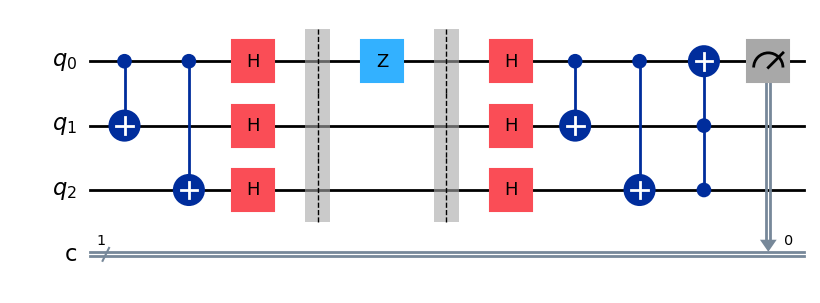

In [ ]:
def phase_flip(i):

    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(1, 'c')

    qc = QuantumCircuit(qr, cr)

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.h(qr[0])
    qc.h(qr[1])
    qc.h(qr[2])
    
    qc.barrier()

    qc.z(qr[i])

    qc.barrier()

    qc.h(qr[0])
    qc.h(qr[1])
    qc.h(qr[2])

    qc.cx(qr[0], qr[1])
    qc.cx(qr[0], qr[2])

    qc.ccx(qr[1], qr[2], qr[0])

    qc.measure(qr[0], cr[0])

    return qc


phase_flip(0).draw('mpl')

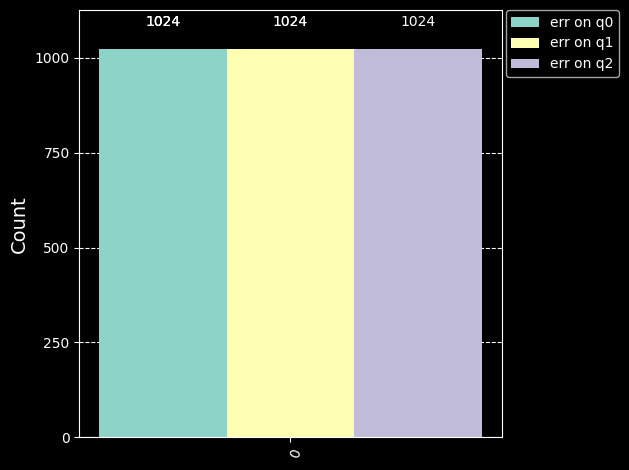

In [22]:
sim = AerSimulator(method='statevector')

qcs = [phase_flip(i) for i in range(3)]

tr_qcs = transpile(qcs, sim)
results = sim.run(tr_qcs).result()
counts = results.get_counts()
plot_histogram(counts, legend=['err on q0', 'err on q1', 'err on q2'])